# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Davi Santos Farias

**Matrícula:** 4052025002520

**Dataset:** [Student Performance Factors Dataset](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/data)

# Descrição do Problema

Esse dataset possui um conjunto de dados com diversos fatores que podem afetar o desempenho de estudantes nos exames. O dataset inclui informação sobre hábitos de estudo, presença nas aulas, involvimento dos pais e outros aspectos que podem influenciar o sucesso acadêmico. O objetivo principal é prever a nota no exame final com base nos dados disponíveis.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **É possível prever qual será a nota no exame com os dados coletados sobre o aluno?**

2. **Existe uma correlação entre o número de horas de estudo e percental de aulas assistidas com as notas nos exames?**

3. **A qualidade de ensino do professor é mais importante do que a motivação do aluno para a nota final nos exames?**

4. **A qualidade do professor possui correlação com o tipo de escola (pública/privada)?**

5. **Alunos com acesso a internet possuem uma tendência a dormir menos horas durante a noite?**

6. **Um aluno que possui uma nota alta no exame anterior pode ter a nota reduzida se sofrer com alta influência de colegas de turma com notas baixas?**

7. **Alunos que participam de atividades extracurriculares e que moram distante da escola tendem a ter notas mais baixas no exame?**

8. **O nível de educação dos parentes influencia na nota do exame final? Será avaliado o involvimento dos parentes na educação.**

9. **Quando o aluno possui défice de aprendizado, a influência de colegas de turma pode melhorar a nota final do exame?**

10. **Existe correlação negativa entre porcentagem de classes atendidas com a distância do aluno à escola?**

## Tipo de Problema

Este é um problema de **regressão supervisionada**. Dado um conjunto de dados, o objetivo é prever a qual a nota do aluno no exame final.

## Seleção de Dados

O dataset Student Performance Factors é um conjunto de dados disponível no Kaggle com licença CC0: Public Domain com expectativa de atualização de dados "Never". Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset Student Performance Factors contém 6.607 registros e possui 20 atributos:

- ***Hours_Studied*** (Número de horas de estudo por semana)
- ***Attendance*** (Porcentage de aulas presenciadas)
- ***Parental_Involvement*** (Nível de envolvimentos dos pais na educação dos alunos (Low, Medium, High))
- ***Access_to_Resources*** (Disponibilidade de recursos educacionais (Low, Medium, High))
- ***Extracurricular_Activities*** (Participação em atividades extracurriculares (Yes, No))
- ***Sleep_Hours*** (Número de horas de sono por noite)
- ***Previous_Scores*** (Nota do exame anterior)
- ***Previous_Scores*** (Nível de motivação do aluno (Low, Medium, High))
- ***Internet_Access*** (Acesso à internet (Yes, No))
- ***Tutoring_Sessions*** (Número de aulas particulares assistidas por mês)
- ***Family_Income*** (Renda familiar (Low, Medium, High))
- ***Teacher_Quality*** (Qualidade de ensino do professor (Low, Medium, High))
- ***School_Type*** (Tipo da escola (Public, Private))
- ***Peer_Influence*** (Influência dos colegas na performance acadêmica (Positive, Neutral, Negative))
- ***Physical_Activity*** (Média de horas praticando atividades físicas por semana)
- ***Learning_Disabilities*** (Presença de dificuldade de aprendizagem (Yes, No))
- ***Parental_Education_Level*** (Nível de educação dos pais (High School, College, Postgraduate))
- ***Distance_from_Home*** (Distância de casa à escola (Near, Moderate, Far))
- ***Gender*** (Gênero do estudante (Male, Female))
- ***Exam_Score*** (Nota final do exame)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Student Performance Factos.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/LucasDSF7/Data-Analysis-Puc-Rio/refs/heads/master/mvp/data/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Student Performance Factors, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Student Performance Factors possui 6.607 instâncias (observações) e 20 atributos. As caractéristicas variam entre o tipo numérico e categórica, com o atributo alvo sendo númerico contínuo, explicando o motivo do problema ser do tipo regressão supervisionada.

É possível observar que alguns atributos (Teacher_Quality, Parental_Education_Level, Distance_from_Home) possuem missings, sendo necessário uma etapa para tratamento desses dados faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## Tratamento de Valores Nulos

Como mencionado, alguns atributos do dataset possuem missing. Podemos ter uma visualização utilizando o método isna() do pandas.

Os atributos com missing são categóricos, então uma boa solução para substituir os missings seria aplicar a moda do atributo no lugar do missing.

Porém, antes de modificar o dataset, é uma boa prática fazer uma copia do dataframe. Para isso, será utilizado o método copy com parâmetro deep=True.

In [88]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [93]:
df_copy = df.copy(deep=True)
df_copy['Teacher_Quality'].replace(np.nan, df['Teacher_Quality'].mode().iloc[0], inplace=True)
df_copy['Parental_Education_Level'].replace(np.nan, df['Parental_Education_Level'].mode().iloc[0], inplace=True)
df_copy['Distance_from_Home'].replace(np.nan, df['Distance_from_Home'].mode().iloc[0], inplace=True)
df_copy.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
def numeric_feature_hist_box_plots(sr: pd.Series) -> None:
    '''
    Returns a tuplu (fig, ax) to plot a histogram and boxplot
    '''
    name = sr.name.replace('_', ' ')
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # Fixing bins to later use in set_xticks method.
    min_v = int(sr.min())
    max_v = int(sr.max()) + 1
    step = (max_v - min_v) // 7
    bins = list(range(min_v, max_v + step, step))
    print(min_v, max_v, bins)
    ax[0].hist(sr, bins=bins)
    ax[0].set_xticks(bins)
    ax[0].set_title(f'{name} Histogram')
    ax[0].set_ylabel('Número de registros')
    ax[0].set_xlabel(sr.name.replace('_', ' '))

    ax[1].boxplot(sr)
    ax[1].set_title(f'{name} Boxplot')

df_copy.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Hours Studied

A média de horas de estudo por semana de 19,97 h/semana é equivalente a uma média de 2,85 h/dia de estudo, que é uma quantidade de horas realista. O desvio padrão é alto (5,99 h/semana) indicando que podemos encontrar tanto alunos dedicados como alunos menos dedicados, como indica o valor máximo de 44 h/semana de estudo e o valor mínimo de 1 h/semana de estudo.

O histograma mostra que o atributo possue uma distribuição normal. Os outliers presentes no Boxplot não parecem representar dados incorretos.

1 45 [1, 7, 13, 19, 25, 31, 37, 43, 49]


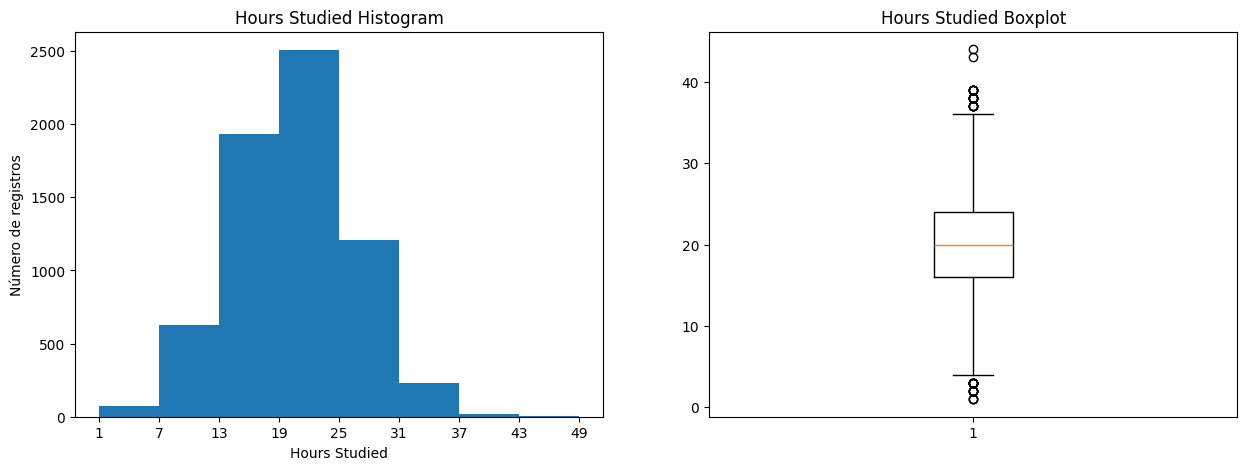

In [ ]:
numeric_feature_hist_box_plots(df_copy['Hours_Studied'])

### Attendance

A média de porcentagem de aulas presenciadas 79,97 % parece razoável e o desvio padrão de 11,54 indica uma concentração de registros por volta de 68 % a 90 %. O valor máximo de 100 % e o valor mínimo de 60 % são realistas, descartando a possibilidade de outliers.

O histograma mostra que o atributo possui uma distribuição uniforme. O boxplot não apresenta outliers.

60 101 [60, 65, 70, 75, 80, 85, 90, 95, 100, 105]


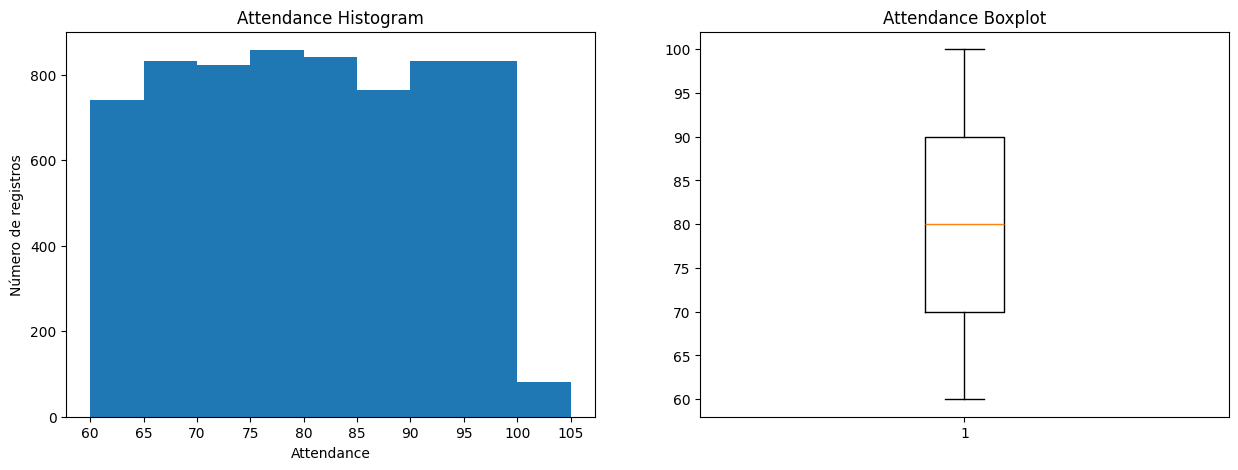

In [ ]:
numeric_feature_hist_box_plots(df_copy['Attendance'])

### Sleep Hours

A média de 7h/dia de sono noturno é realista, com um desvio padrão de 1,47 indicando que a maior parte dos registros ficam próximos a média. O valor mínimo de 4h/dia e o máximo de 10h/dia são razoáveis e indicam que não existem outliers.

A histograma mostra que o atributo possue uma distribuição normal. O boxplot não apresenta outliers.

4 11 [4, 5, 6, 7, 8, 9, 10, 11]


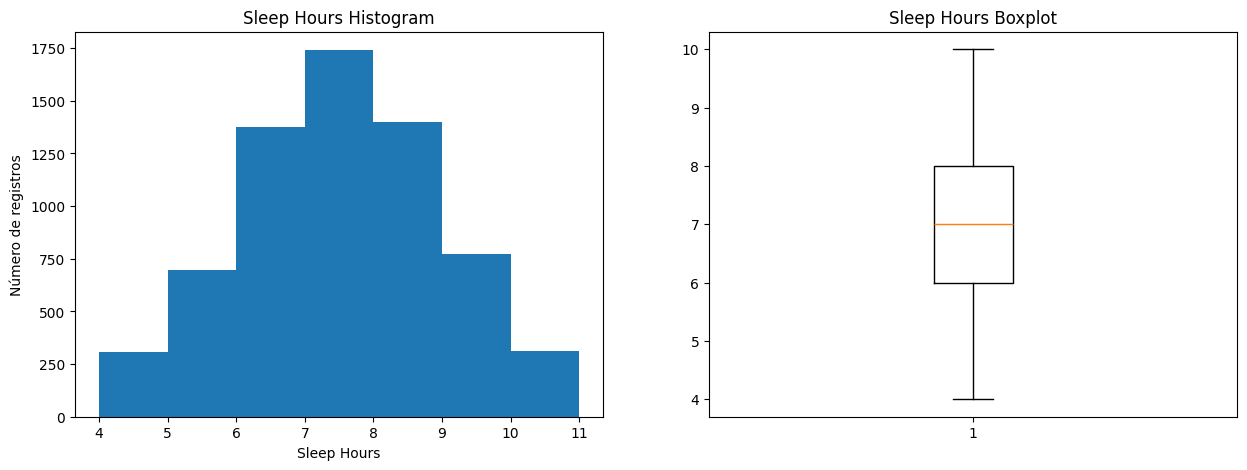

In [ ]:
numeric_feature_hist_box_plots(df_copy['Sleep_Hours'])

### Previous Scores

A média de 75 pontos é factível. O valor mínimo de 50 pontos e o valor máximo de 100 pontos são razoáveis indicando que o atributo não possui outliers.

O histograma mostra que o atributo possui uma distribuição uniforme. O boxplot não apresenta outliers.

50 101 [50, 57, 64, 71, 78, 85, 92, 99, 106]


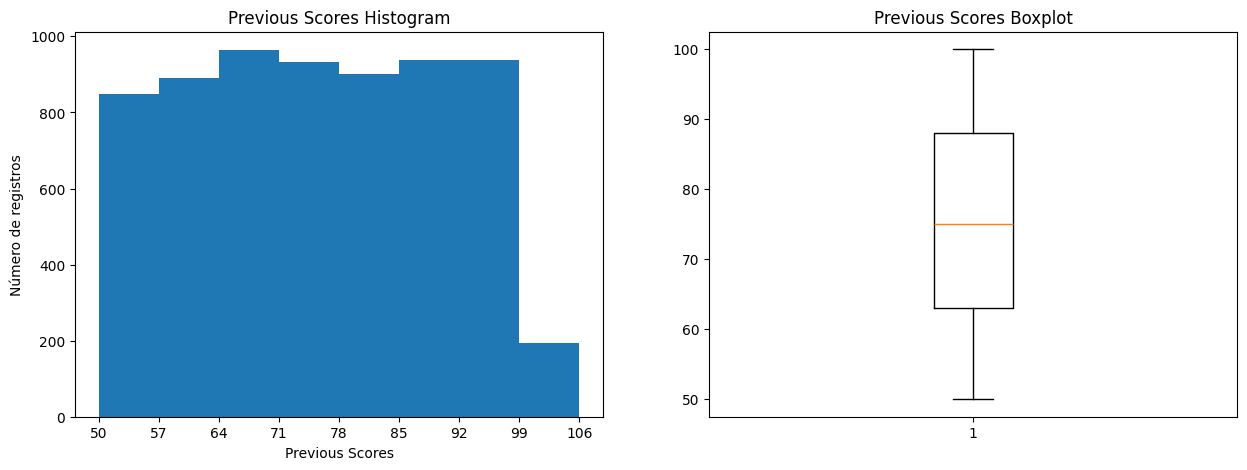

In [ ]:
numeric_feature_hist_box_plots(df_copy['Previous_Scores'])

### Tutoring Sessions

A média de 1,49 de aulas privadas por mês é razoável, não deve ser comum essa prática entre os alunos avaliados. O valor mínimo de 0 é factível e não pode ser considerado missing, pois é perfeitamente normal o alumo não ter aulas privadas. O valor máximo de 8 equivale a uma média de 2 aulas privadas por semana, que também é possível.

O histograma indica que o atributo possui uma distribuição assimétrica à direita, mostrando que o mais comum é ter menos aulas particulares durante o mês. O boxplot indica a presença de outliers, mas dada a característica do atributo, esses dados não podem ser considerados erros.

0 9 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


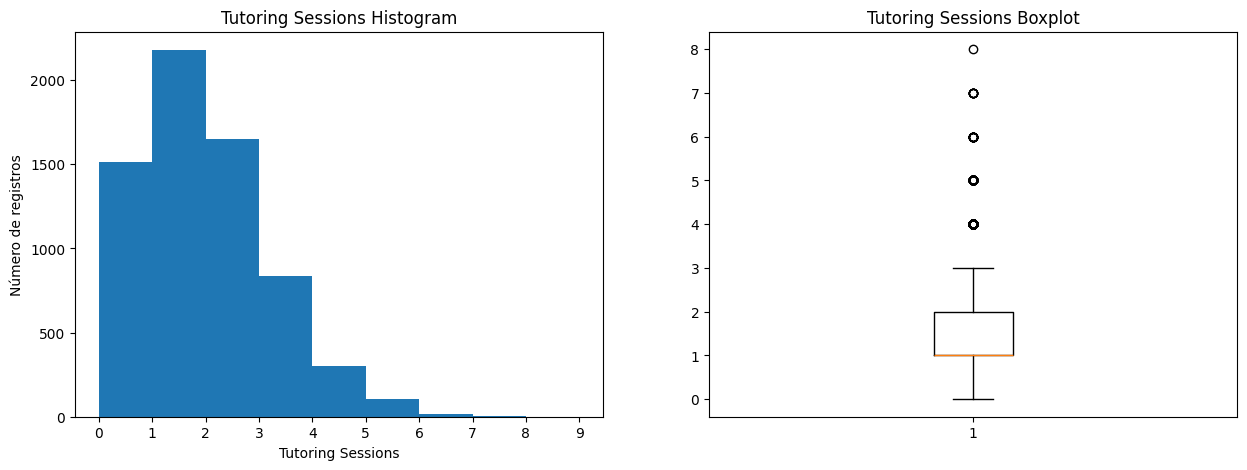

In [ ]:
numeric_feature_hist_box_plots(df_copy['Tutoring_Sessions'])

### Physical Activity

O valor médio de 2,97 h/semana é relativamente alto para estudantes. Analisando o histograma do atributo é possível notar que possui uma distribuição normal, quando talvez o esperado fosse uma distribuição assímetrica à direita, com muitos alunos tendo um número de horas de atividades físicas próxima a zero. Uma explicação para esse atributo com moda de 3 horas por semana seria existir uma disciplina de atividade física na grade curricular dos alunos.

O histograma indica uma distribuição normal. O boxplot não apresenta outliers.

0 7 [0, 1, 2, 3, 4, 5, 6, 7]


0    3
Name: Physical_Activity, dtype: int64

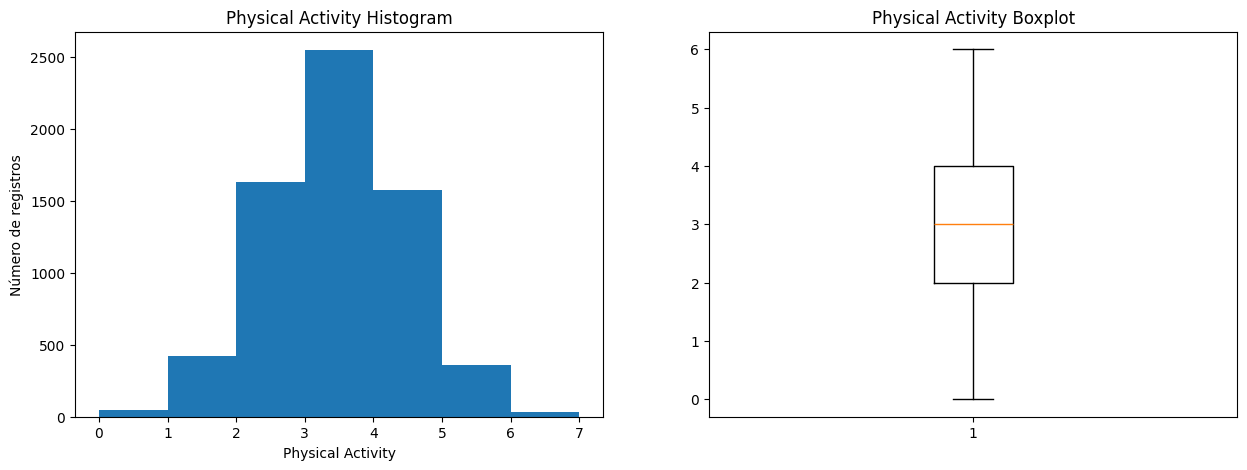

In [ ]:
numeric_feature_hist_box_plots(df_copy['Physical_Activity'])
df['Physical_Activity'].mode()

### Exam Score

Ocorreu algum evento entre o exame anterior e o exame atual. No exame anterior existia uma distribuição uniforme dos dados, enquanto que no exame atual a distribuição é normal com moda 68.

O histograma apresenta uma distribuição normal. O boxplot apresenta outliers, mas esses valores não podem ser considerados erro.

55 102 [55, 61, 67, 73, 79, 85, 91, 97, 103]


0    68
Name: Exam_Score, dtype: int64

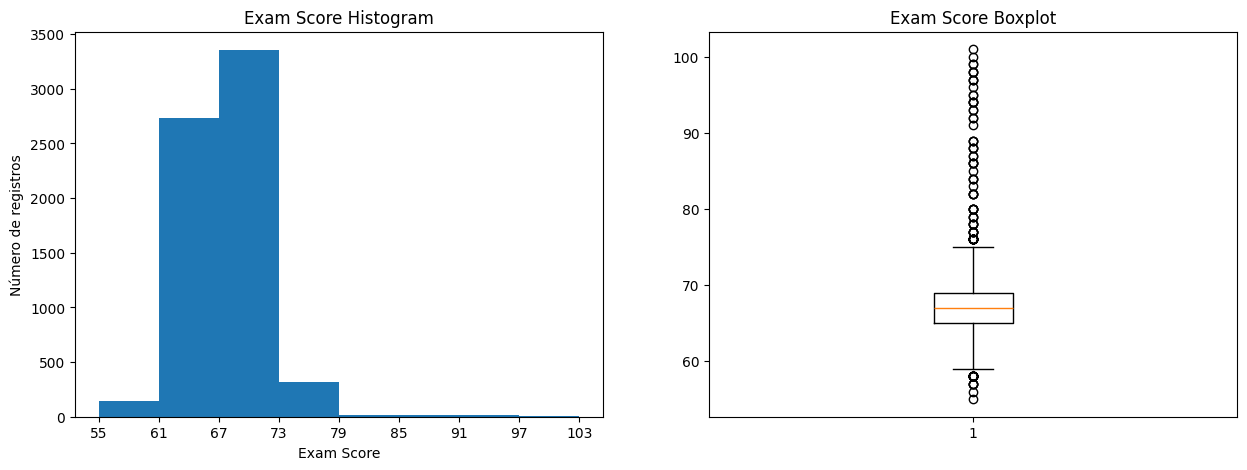

In [ ]:
numeric_feature_hist_box_plots(df_copy['Exam_Score'])
df['Exam_Score'].mode()

### Scatter Plot

A seguir, scatter plot entre as variáveis numéricas.

O maior ponto de interesse é a relação das variáveis com Exam_Score. Podemos notar que as variáveis Hours_Studied e Attendance possuem uma certa correlação com Exam_Score. Isso pode ser confirmado utilizando o heatmap de correlação usando o método de Pearson.

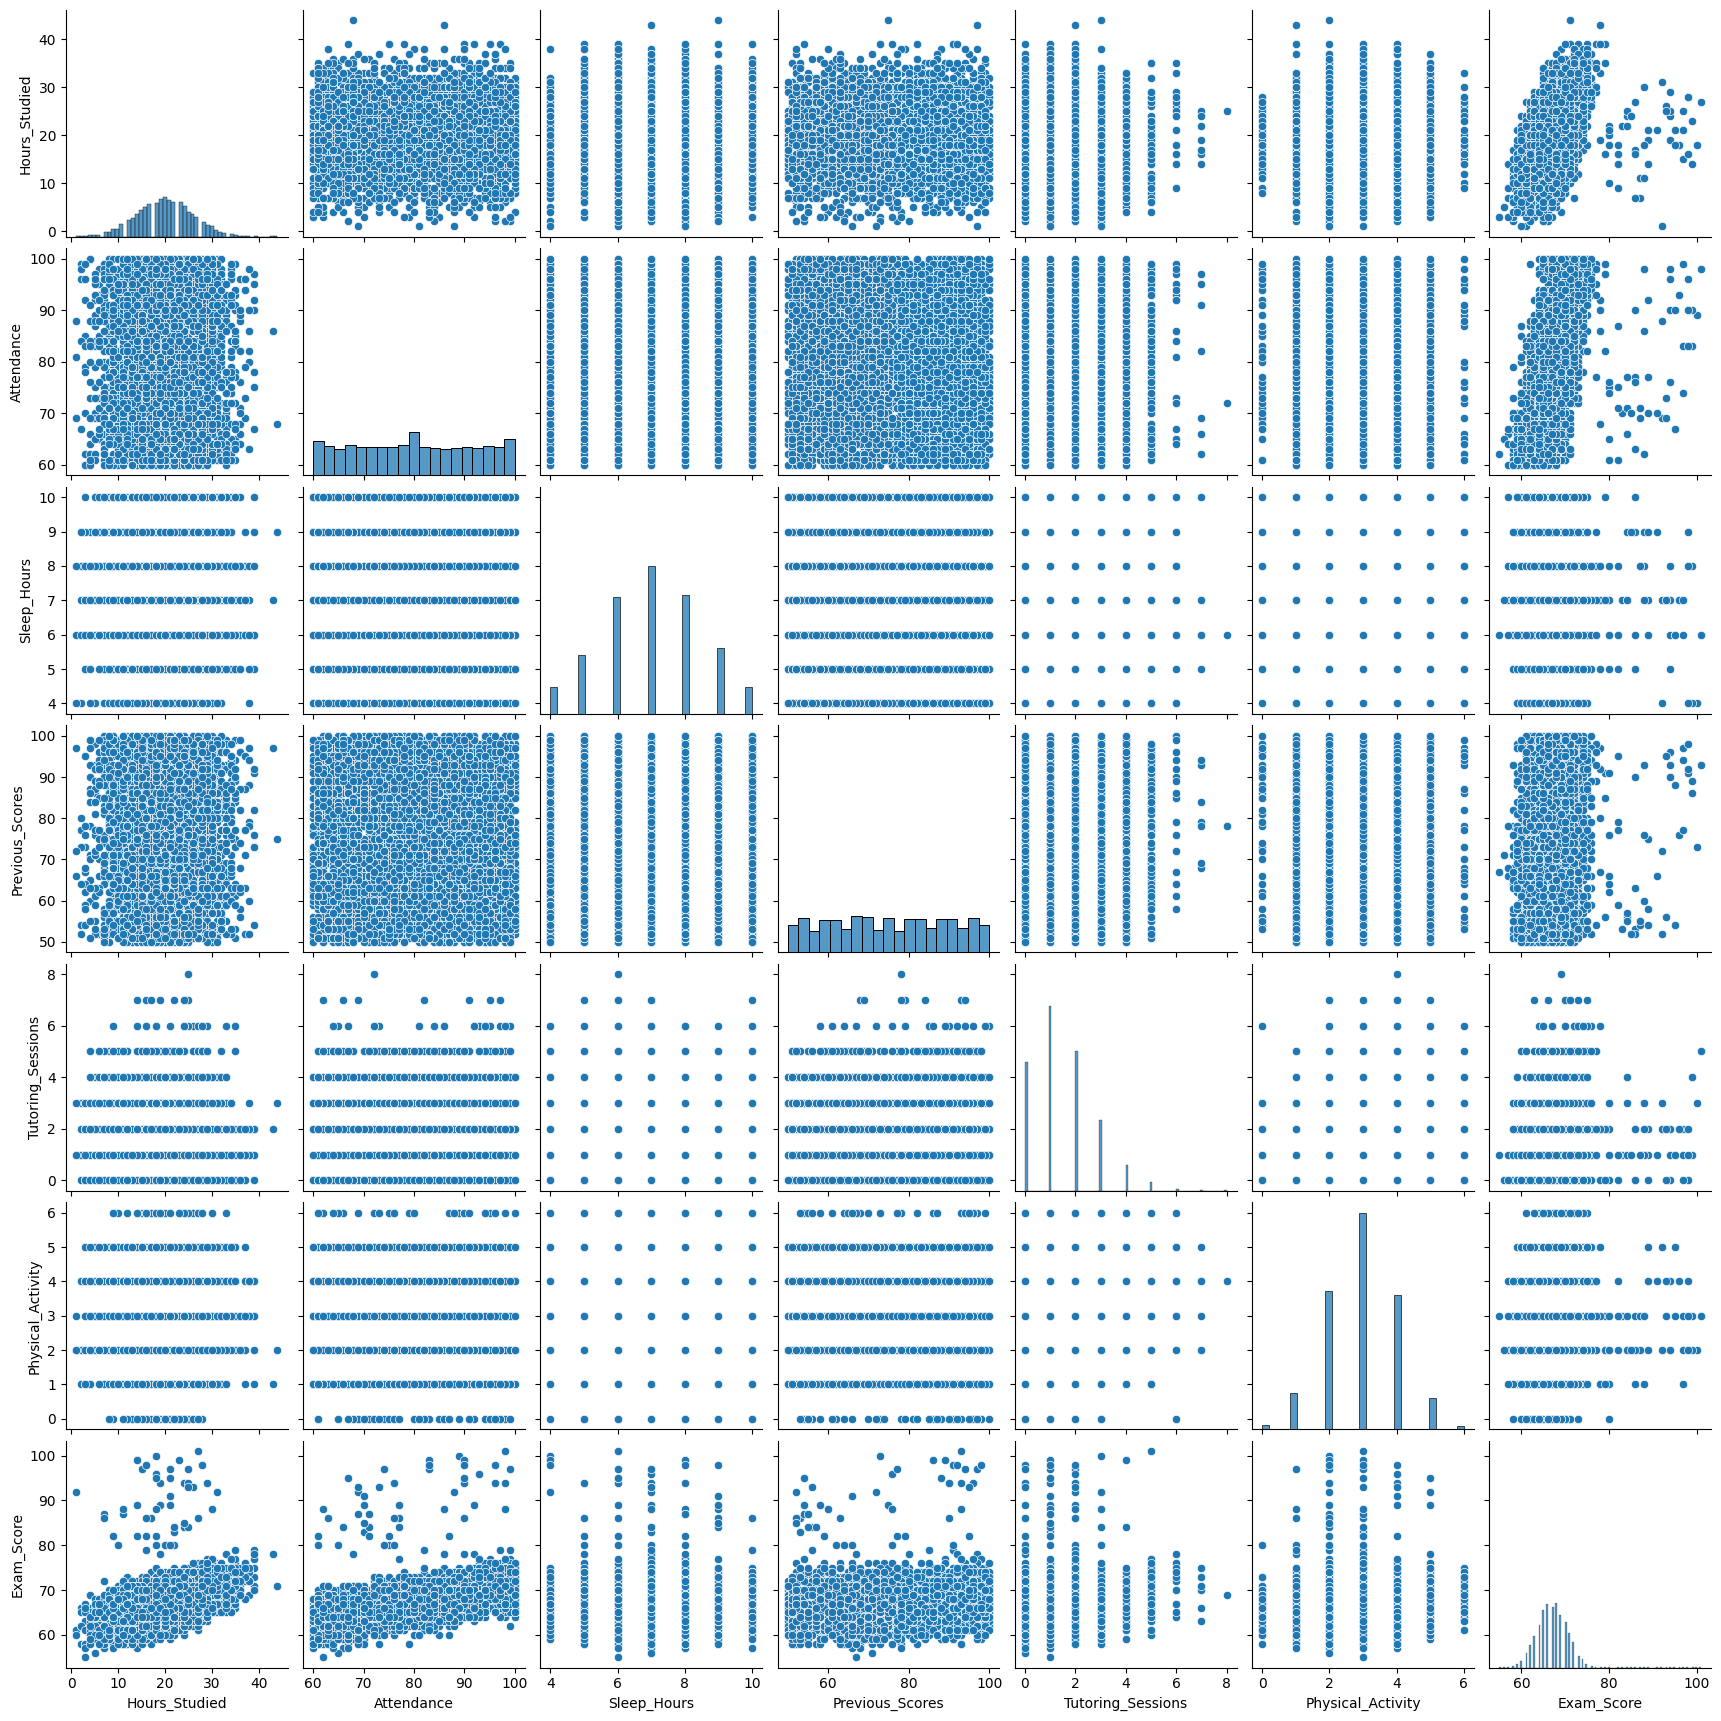

In [ ]:
sns.pairplot(df_copy)